# 📊 **AP Statistics — Unit 1**

## 🔎 Lesson 2: Exploring Quantitative Data

> ### 💭 Investigation Question
>
> **What can we discover about a large dataset that we cannot easily see from raw numbers alone?**

---

### 🚀 Today, You Become the Statistician

Imagine receiving a spreadsheet containing information about **600 students**.

Hundreds of rows. Thousands of numbers.

At first glance, it may look like nothing more than a giant collection of values...

**But hidden inside those numbers are patterns.** 🔍

Who sleeps the most? 😴  
How much time do students spend on screens? 📱  
Are most students similar, or is there a lot of variation?  
Are there observations that seem unusual? 👀  

Today, we are going to use **Python, graphs, and statistical thinking** to turn this:

> 🔢 **Raw Data**

into this:

> 📊 **Patterns → Statistics → Conclusions**

---

## 🎯 Learning Goals

By the end of this investigation, you will be able to:

- 💻 **Explore** a large quantitative dataset using technology.
- 📊 **Construct and interpret histograms** to reveal patterns in data.
- 🔍 Describe a distribution using:
  - **Shape**
  - **Center**
  - **Spread**
  - **Unusual features**
- 🎛️ Investigate how changing histogram settings can change the way a distribution **appears**.
- ✍️ Write clear **statistical conclusions in context**.

---

### 🧠 Remember

Statistics is not just about calculating numbers.

> **The goal is to use data to understand what is happening — and communicate what you discover.**

Let's start exploring. 🚀

## 1. Load the Excel Dataset

Upload `AP_Statistics_Unit1_Lesson1_Exploration_Dataset.xlsx`.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving AP_Statistics_Unit1_Lesson1_Exploration_Dataset.xlsx to AP_Statistics_Unit1_Lesson1_Exploration_Dataset.xlsx


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename = next(iter(uploaded))
df = pd.read_excel(filename, sheet_name="Student Data", header=3)
df.head()

,Student_ID,Sleep_Hours,Screen_Time_Hours,Study_Time_Hours,Exercise_Hours,Commute_Minutes,States_Provinces_Visited,Countries_Visited
0,1001,7.4,4.4,1.3,1.6,35,6,3
1,1002,6.5,2.5,3.2,0.5,34,15,4
2,1003,7.8,6.6,0.5,0.7,40,7,4
3,1004,5.9,6.9,0.6,0.4,26,4,5
4,1005,6.9,5.3,1.4,1.3,12,7,1


# 📊 Meet the Data

In this lesson, we will work with a dataset containing information about **600 students** and different aspects of their daily lives and experiences.


---

## 🔎 Understanding the Dataset

In a dataset:

- Each **row** represents one student (one observation).
- Each **column** represents a variable recorded for that student.
- Each **cell** contains the value of a particular variable for a particular student.

For example:

| Student ID | Sleep | Screen Time | Study Time | Exercise |
|---|---:|---:|---:|---:|
| 1001 | 7.4 h | 4.4 h | 1.3 h | 1.6 h |

Student **1001**, for example, reports approximately **7.4 hours of sleep**, **4.4 hours of non-school screen time**, **1.3 hours of study time**, and **1.6 hours of exercise per day**.

---

## 📋 Variables in the Dataset

| Variable | Description | Unit |
|---|---|---|
| `Student_ID` | Anonymous number identifying each observation | — |
| `Sleep_Hours` | Average amount of sleep per night | Hours |
| `Screen_Time_Hours` | Average daily non-school screen time | Hours |
| `Study_Time_Hours` | Average daily time spent studying or doing homework | Hours |
| `Exercise_Hours` | Average daily time spent exercising or being physically active | Hours |
| `Commute_Minutes` | One-way travel time to school | Minutes |
| `States_Provinces_Visited` | Number of states or provinces visited | Count |
| `Countries_Visited` | Number of countries visited | Count |

---

## 🧠 Before We Analyze the Data...

Our dataset contains **600 observations**.

Imagine trying to understand all 600 students simply by scrolling through the spreadsheet.

Can you easily answer these questions?

- How many hours of sleep are typical for these students?
- What does a typical amount of screen time look like?
- Are there students with unusually high or low values?
- How spread out are the observations?
- Are the values concentrated in one area?
- What does the overall distribution look like?

With **600 observations**, answering these questions from the raw data alone becomes difficult.

### This is why we use statistics.

In this lesson, we will transform a large collection of raw numbers into:

**DATA → GRAPHS → STATISTICS → INTERPRETATION**

Our goal is not simply to calculate numbers.

Our goal is to **discover and communicate the story hidden inside the data.**

## 2. First Look at some Observations

Before calculating anything, inspect the data.

**Discuss:**
1. What can you learn easily from the raw table?
2. What is difficult to see from hundreds of rows?
3. Could you confidently identify the shape, center, or spread just by scrolling?

In [4]:
print("Number of observations:", len(df))
print("\nVariables:")
print(list(df.columns))
df.sample(20, random_state=7)

Number of observations: 600

Variables:
['Student_ID', 'Sleep_Hours', 'Screen_Time_Hours', 'Study_Time_Hours', 'Exercise_Hours', 'Commute_Minutes', 'States_Provinces_Visited', 'Countries_Visited']


,Student_ID,Sleep_Hours,Screen_Time_Hours,Study_Time_Hours,Exercise_Hours,Commute_Minutes,States_Provinces_Visited,Countries_Visited
261,1262,6.9,2.5,1.1,2.9,2,3,3
132,1133,7.0,0.9,0.9,2.3,26,5,2
575,1576,7.4,3.8,3.5,0.2,50,5,5
454,1455,6.6,3.5,1.2,1.8,43,5,4
337,1338,7.4,8.4,1.6,0.1,42,11,3
580,1581,5.9,4.5,2.1,0.3,26,9,1
316,1317,6.8,4.0,0.2,0.1,50,3,0
439,1440,6.3,4.3,1.8,1.6,35,5,5
53,1054,6.1,5.8,2.7,1.3,64,14,5
397,1398,7.6,2.7,3.5,1.5,61,3,5


## 3. Investigate Screen Time

Before graphing, predict:

- Where will most observations fall?
- Will the distribution be symmetric or skewed?
- Will there be unusual values?

In [4]:
screen = df["Screen_Time_Hours"]
screen.head(20)

,Screen_Time_Hours
0,4.4
1,2.5
2,6.6
3,6.9
4,5.3
5,4.9
6,4.1
7,2.3
8,6.8
9,3.5


## 4. Create a Histogram

We have **600 screen-time observations**.

Looking at a few values is easy:

`4.4, 2.5, 6.6, 6.9, 5.3, 4.9, ...`

But looking at **600 individual numbers** makes it difficult to see the overall pattern.

So instead of examining every observation separately, we can **group similar values together**.

This is the basic idea behind a **histogram**.

> 💡 A histogram divides quantitative data into intervals called **bins** and counts how many observations fall into each bin.

Let's build one step by step.

### Step 1️⃣ — Find the Range of the Data

Before creating intervals, we need to know where our data begins and ends.

Python found:

- **Minimum:** the smallest screen-time observation
- **Maximum:** the largest screen-time observation

So our histogram needs to cover all values from the minimum to the maximum.

In [6]:
minimum = screen.min()
maximum = screen.max()

print("Minimum screen time:", minimum, "hours")
print("Maximum screen time:", maximum, "hours")

Minimum screen time: 0.5 hours
Maximum screen time: 13.0 hours


### Step 2️⃣ — Divide the Data into Bins

We want **10 bins**.

A **bin** is simply an interval of values.

we can divide the distance between the minimum and maximum into 10 equal-width intervals.

For example, we might obtain intervals similar to:

| Bin | Screen Time |
|---|---|
| 1 | 0.5 – 1.74 hours |
| 2 | 1.74 – 2.98 hours |
| 3 | 2.98 – 4.22 hours |
| ... | ... |
| 10 | 11.66 – 12.90 hours |

Each student will belong to one of these intervals based on their screen time.

Now we need to answer:

> **How many students fall inside each interval?**

In [7]:
# Calculate frequencies and bin boundaries
frequencies, bin_edges = np.histogram(screen, bins=10)

# Put the results into a DataFrame
frequency_table = pd.DataFrame({
    "Interval (hours)": [
        f"{bin_edges[i]:.2f} – {bin_edges[i+1]:.2f}"
        for i in range(len(frequencies))
    ],
    "Number of Students": frequencies
})

frequency_table

,Interval (hours),Number of Students
0,0.50 – 1.75,31
1,1.75 – 3.00,108
2,3.00 – 4.25,145
3,4.25 – 5.50,125
4,5.50 – 6.75,74
5,6.75 – 8.00,41
6,8.00 – 9.25,35
7,9.25 – 10.50,12
8,10.50 – 11.75,7
9,11.75 – 13.00,22


### Step 3️⃣ — Count the Observations

Now we have something much easier to understand.

Instead of looking at **600 individual screen-time values**, we have grouped them into only **10 intervals**.

For each interval, Python counted the number of students whose screen time falls inside it.

This count is called the **frequency**.

For example:

> If 120 students have screen times between 3 and 4 hours, the frequency of that interval is **120**.

We can now represent these frequencies visually.

Each interval becomes a **bar**.

The **height of the bar** represents the number of observations in that interval.

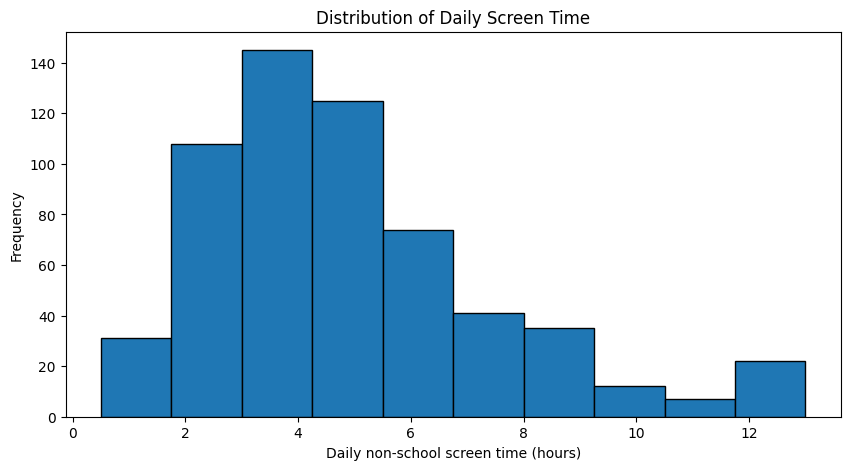

In [8]:
plt.figure(figsize=(10,5))
plt.hist(screen, bins=10, edgecolor="black")
plt.xlabel("Daily non-school screen time (hours)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Screen Time")
plt.show()

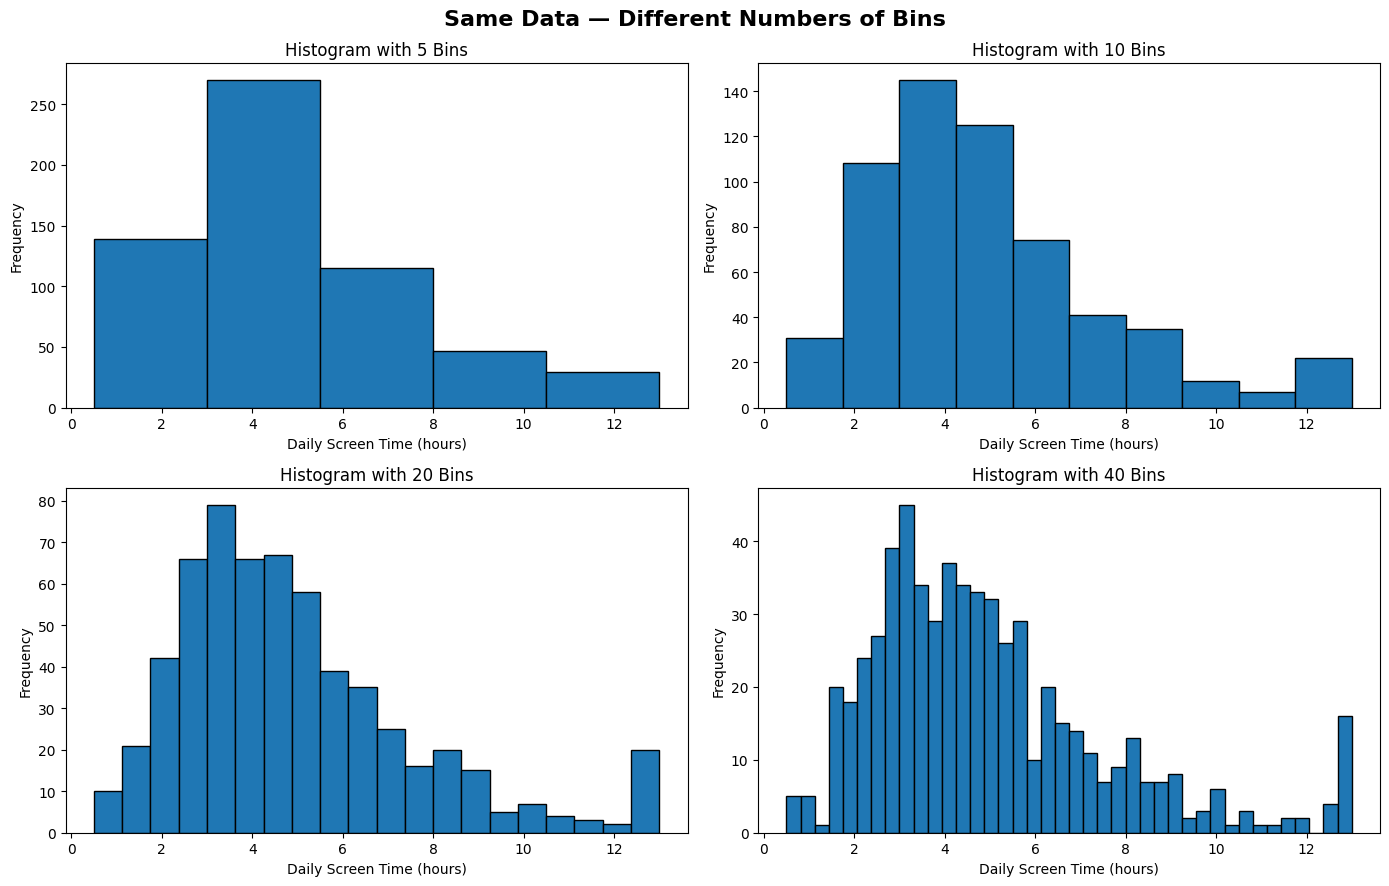

In [9]:
# Compare the same data using different numbers of bins

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

bin_options = [5, 10, 20, 40]

for ax, bins in zip(axes.flatten(), bin_options):

    ax.hist(
        screen,
        bins=bins,
        edgecolor="black"
    )

    ax.set_title(f"Histogram with {bins} Bins")
    ax.set_xlabel("Daily Screen Time (hours)")
    ax.set_ylabel("Frequency")

plt.suptitle(
    "Same Data — Different Numbers of Bins",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### 🔎 Same Data — Different Story?

All four histograms were created using **exactly the same 600 observations**.

The only thing we changed was the **number of bins**.

##### 👀 Compare the four graphs

Ask yourself:

1. Which histogram makes the overall **shape** easiest to see?
2. What information is hidden when we use only **5 bins**?
3. What new details appear with **10 or 20 bins**?
4. What happens when we increase the number to **40 bins**?
5. Does having more bins always produce a better histogram?



The number of bins affects how a distribution **appears**.

**Too few bins**  
→ observations are grouped into very wide intervals  
→ important features may be hidden.

**Too many bins**  
→ intervals become very narrow  
→ the graph may become noisy and make the overall pattern harder to see.

**A reasonable number of bins**  
→ reveals enough detail while keeping the overall shape of the distribution visible.

> 💡 There is no single "correct" number of bins.

A statistician should experiment with different bin widths and choose a display that represents the distribution clearly.

## 🔍 What Does the Histogram Tell Us?

We now know **how** a histogram is constructed.

But creating a graph is only the beginning.

The real job of a statistician is to ask:

> ### **What is the data telling us?**

A histogram allows us to see the **distribution** of a quantitative variable.

When examining a distribution, we focus on four important features:

### 🔷 Shape  
What does the overall distribution look like?

### 🎯 Center  
Where is a typical observation located?

### ↔️ Spread  
How much do the observations vary?

### ⚠️ Unusual Features  
Are there gaps, clusters, or observations that stand out?

Let's investigate each one using our **screen-time data**.


### 1️⃣ Shape

The distribution of **daily screen time is skewed to the right**.

Most students have screen times concentrated in the lower-to-middle part of the distribution, while a smaller number of students report much larger amounts of screen time.

This creates a **longer tail on the right side** of the histogram.

> ⚠️ **Important:**  
> "Skewed right" does **not** mean that most observations are on the right.

It means that the **tail of the distribution extends toward the right**.

### 2️⃣ Center — Where Is a Typical Observation?

Once we understand the shape, we want to know where the distribution is **centered**.

In simple terms:

> 🎯 **What amount of screen time would we consider typical for a student in this dataset?**

There are two important measures of center:

- **Mean**
- **Median**

Let's calculate both.

In [10]:
mean_screen = screen.mean()
median_screen = screen.median()

print(f"Mean: {mean_screen:.2f} hours")
print(f"Median: {median_screen:.2f} hours")

Mean: 4.92 hours
Median: 4.40 hours


### 🤔 Think About It

Compare the two values.

- Which is larger: the **mean** or the **median**?
- Remember that our distribution is **skewed right**.
- What effect might the unusually large screen-time observations have on the mean?

> **Which measure do you think better represents a typical student's screen time? Why?**

### 3️⃣ Spread — How Much Do the Students Differ?

Knowing the center is useful, but it does **not** tell us the whole story.

Imagine two classes:

- In **Class A**, almost every student reports about 4 hours of screen time.
- In **Class B**, some students report 1 hour while others report 8 hours.

Both classes could have the **same mean**, but their distributions would look very different.

The difference is called **variability** or **spread**.

> ↔️ **Spread describes how much the observations vary from one another.**

Let's measure the spread of our screen-time data.

#### 📏 Range

The **range** measures the distance between the smallest and largest observations.
$$
Range = Maximum - Minimum
$$
Let's calculate it.

In [11]:
minimum = screen.min()
maximum = screen.max()
data_range = maximum - minimum

print(f"Minimum: {minimum:.2f} hours")
print(f"Maximum: {maximum:.2f} hours")
print(f"Range: {data_range:.2f} hours")

Minimum: 0.50 hours
Maximum: 13.00 hours
Range: 12.50 hours


#### 📦 Looking at the Middle 50%

Instead of using only the smallest and largest observations, we can focus on the **middle half of the data**.

To do this, we use **quartiles**.

##### Q1 — First Quartile

About **25% of the observations** are at or below Q1.

##### Q2 — Median

About **50% of the observations** are at or below the median.

##### Q3 — Third Quartile

About **75% of the observations** are at or below Q3.

Together, Q1 and Q3 allow us to measure the spread of the **middle 50% of the observations**.

In [12]:
Q1 = screen.quantile(0.25)
median = screen.median()
Q3 = screen.quantile(0.75)

print(f"Q1:     {Q1:.2f} hours")
print(f"Median: {median:.2f} hours")
print(f"Q3:     {Q3:.2f} hours")

Q1:     3.10 hours
Median: 4.40 hours
Q3:     6.22 hours


#### 📐 Interquartile Range — IQR

The **Interquartile Range (IQR)** measures the width of the middle 50% of the data.
$$
IQR = Q_3 - Q_1
$$
Unlike the range, the IQR is much less affected by extremely small or extremely large observations.

In [13]:
IQR = Q3 - Q1

print(f"IQR = {Q3:.2f} - {Q1:.2f}")
print(f"IQR = {IQR:.2f} hours")

IQR = 6.22 - 3.10
IQR = 3.12 hours


##### 🧠 What Does the IQR Actually Mean?

Suppose we obtain:

> **IQR = 3.2 hours**

Do not simply write:

> ❌ "The IQR is 3.2."

Instead, interpret it:

> ✅ **The middle 50% of students' daily screen times span approximately 3.2 hours.**

Remember:

**Statistics should always be interpreted in the context of the data.**

#### 📦 From the IQR to a Boxplot

We have calculated:

- **Q1** — the 25th percentile
- **Median (Q2)** — the 50th percentile
- **Q3** — the 75th percentile
- **IQR = Q3 − Q1**

A **boxplot** turns these numerical summaries into a visual representation of the distribution.

The central box represents the **middle 50% of the data**.

Let's create one for our screen-time data.

## 4️⃣ Unusual Features — Are Any Observations Unusually Far Away?

Look again at the right side of our histogram.

There are a few students with much larger screen times than most of the group.

But should we simply call them **outliers** because they look unusual?

Not necessarily.

Statistics gives us a rule that can help identify **potential outliers**.

### **The 1.5 × IQR Rule**

An observation is considered a **potential outlier** if it is:
$$
 Q_1 - 1.5(IQR)
$$
or
$$
 Q_3 + 1.5(IQR)
$$
These values are called the **lower fence** and **upper fence**.

## 📦 The Box

The box extends from **$Q_1$ to $Q_3$**.

Therefore, the width of the box represents the **Interquartile Range**:

$$
IQR = Q_3 - Q_1
$$

The box contains the **middle 50% of the observations**.

### ➖ The Line Inside the Box

The line inside the box represents the **median ($Q_2$)**.

Approximately **50% of observations are below the median** and **50% are above it**.

### ⚫ Potential Outliers

Potential outliers are observations satisfying:

$$
x < Q_1 - 1.5(IQR)
$$

or

$$
x > Q_3 + 1.5(IQR)
$$

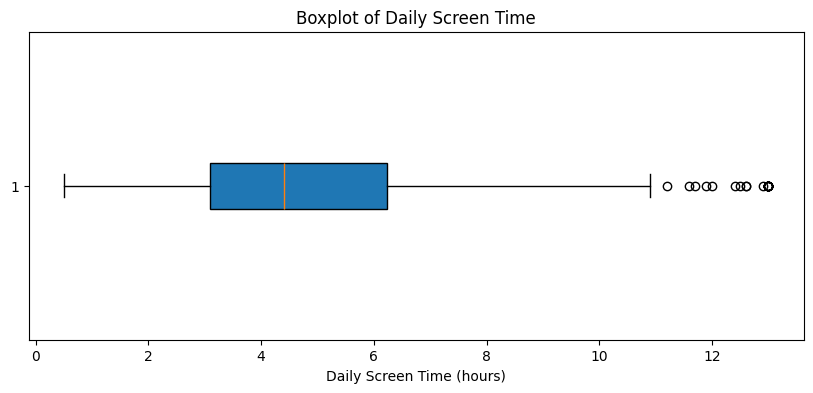

In [14]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    screen,
    vert=False,
    patch_artist=True
)

plt.xlabel("Daily Screen Time (hours)")
plt.title("Boxplot of Daily Screen Time")

plt.show()

## 7. Your Turn

Choose one variable:

- `Sleep_Hours`
- `Study_Time_Hours`
- `Exercise_Hours`
- `Commute_Minutes`
- `States_Provinces_Visited`
- `Countries_Visited`

Change the variable below.

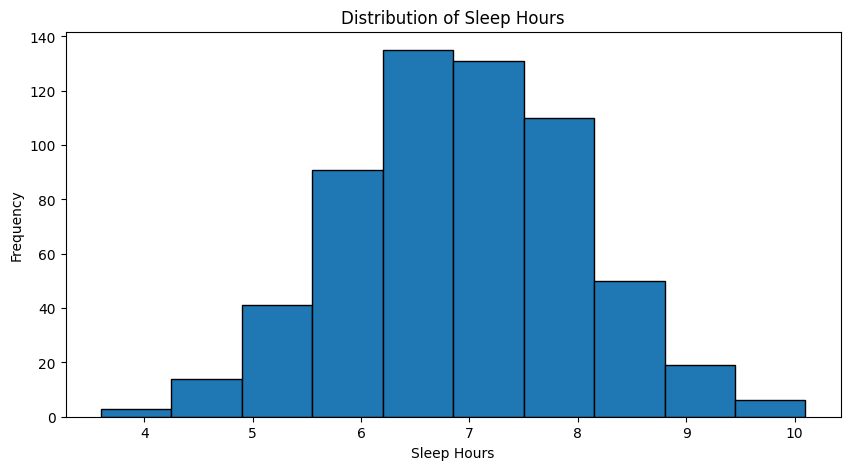

In [15]:
variable = "Sleep_Hours"  # Change this
x = df[variable]

plt.figure(figsize=(10,5))
plt.hist(x, bins=10, edgecolor="black")
plt.xlabel(variable.replace("_"," "))
plt.ylabel("Frequency")
plt.title(f"Distribution of {variable.replace('_',' ')}")
plt.show()

In [16]:
pd.Series({
    "Minimum": x.min(),
    "Q1": x.quantile(0.25),
    "Median": x.median(),
    "Mean": x.mean(),
    "Q3": x.quantile(0.75),
    "Maximum": x.max(),
    "IQR": x.quantile(0.75) - x.quantile(0.25),
    "Standard Deviation": x.std()
}).round(2)

,0
Minimum,3.60
Q1,6.20
Median,6.90
Mean,6.90
Q3,7.60
Maximum,10.10
IQR,1.40
Standard Deviation,1.07


# 📏 Extending Our Study of Variability

So far, we have used the **range** and **IQR** to describe spread.

The IQR focuses on the **middle 50%** of the observations.

But statisticians also use a measure of variability that considers **every observation** in the dataset:

> ## **Standard Deviation**

To understand standard deviation, we first need to understand how far individual observations are from the mean.

## 1️⃣ Deviations from the Mean

For an observation $x$, its **deviation from the mean** is:

$$
\text{Deviation} = x - \bar{x}
$$

where:

- $x$ = an individual observation
- $\bar{x}$ = the sample mean

A positive deviation means the observation is **above the mean**.

A negative deviation means the observation is **below the mean**.

In [17]:
mean_screen = screen.mean()

deviation_table = pd.DataFrame({
    "Screen Time (hours)": screen.head(10),
    "Mean Screen Time": mean_screen,
    "Deviation from Mean": screen.head(10) - mean_screen
})

display(
    deviation_table.style
    .format({
        "Screen Time (hours)": "{:.2f}",
        "Mean Screen Time": "{:.2f}",
        "Deviation from Mean": "{:.2f}"
    })
    .hide(axis="index")
)

Screen Time (hours),Mean Screen Time,Deviation from Mean
4.40,4.92,-0.52
2.50,4.92,-2.42
6.60,4.92,1.68
6.90,4.92,1.98
5.30,4.92,0.38
4.90,4.92,-0.02
4.10,4.92,-0.82
2.30,4.92,-2.62
6.80,4.92,1.88
3.50,4.92,-1.42


### 🤔 Think About It

Look at the deviations.

1. Why are some deviations positive?
2. Why are some negative?
3. What would a deviation close to 0 mean?
4. Which students in the table are farthest from the mean?

The farther observations tend to be from the mean, the greater the **variability** of the distribution.

# 📐 Standard Deviation and Variance

The **standard deviation** measures the typical distance of observations from the mean.

For a sample, the standard deviation is:

$$
s=\sqrt{\frac{\sum (x_i-\bar{x})^2}{n-1}}
$$

The quantity before taking the square root is called the **sample variance**:

$$
s^2=\frac{\sum (x_i-\bar{x})^2}{n-1}
$$

### How should we interpret standard deviation?

- A **small** standard deviation means observations tend to be close to the mean.
- A **large** standard deviation means observations are more spread out around the mean.
- Standard deviation has the **same units as the original variable**.
- Variance has **squared units**, which makes standard deviation easier to interpret in context.

In [18]:
screen_variance = screen.var()
screen_sd = screen.std()

print(f"Mean Screen Time: {screen.mean():.2f} hours")
print(f"Variance: {screen_variance:.2f} hours²")
print(f"Standard Deviation: {screen_sd:.2f} hours")

Mean Screen Time: 4.92 hours
Variance: 6.84 hours²
Standard Deviation: 2.61 hours


### ✍️ Interpret in Context

Complete the sentence using the result above:

> Students' daily non-school screen times typically vary from the mean screen time by approximately **_____ hours**.

Remember: calculating a statistic is only part of the job. In AP Statistics, we also need to **interpret it in context**.

# 🛡️ Resistant and Nonresistant Statistics

Do extreme observations affect every statistic equally?

Let's test it.

We will take the original screen-time data and change **one observation** to an extremely large value: **50 hours**.

Then we will compare the summary statistics before and after the change.

In [19]:
original = screen.copy()

modified = screen.copy()
modified.iloc[0] = 50

comparison = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Range", "IQR", "Standard Deviation"],
    "Original Data": [
        original.mean(),
        original.median(),
        original.max() - original.min(),
        original.quantile(0.75) - original.quantile(0.25),
        original.std()
    ],
    "After One Extreme Value": [
        modified.mean(),
        modified.median(),
        modified.max() - modified.min(),
        modified.quantile(0.75) - modified.quantile(0.25),
        modified.std()
    ]
})

display(
    comparison.style
    .format({
        "Original Data": "{:.2f}",
        "After One Extreme Value": "{:.2f}"
    })
    .hide(axis="index")
)

Statistic,Original Data,After One Extreme Value
Mean,4.92,5.00
Median,4.40,4.40
Range,12.50,49.50
IQR,3.12,3.20
Standard Deviation,2.61,3.20


### 🔎 What Changed?

Statistics that are not strongly affected by extreme observations are called **resistant statistics**.

| Resistant | Not Resistant |
|---|---|
| Median | Mean |
| IQR | Standard deviation |
|  | Range |

### 🧠 Important Connection

For a distribution that is approximately **symmetric with no strong outliers**, the **mean and standard deviation** are often useful summaries.

For a distribution that is strongly **skewed or contains outliers**, the **median and IQR** are usually more resistant summaries.

### Your Turn

For our screen-time distribution, which pair would you choose?

**A. Mean and standard deviation**

**B. Median and IQR**

Explain your choice using the **shape and unusual features** of the distribution.

# 📍 Percentiles — Where Does an Observation Stand?

So far, we have described the entire distribution.

Now suppose we want to describe the **relative position of one student**.

A **percentile** tells us approximately what percentage of observations are **at or below** a particular value.

For example:

> A student at the **80th percentile** for screen time has a screen-time value greater than or equal to approximately 80% of the observations in the dataset.

Quartiles are special percentiles:

- $Q_1$ = 25th percentile
- Median = 50th percentile
- $Q_3$ = 75th percentile

In [20]:
student_value = 6.0

percentile = (screen <= student_value).mean() * 100

print(f"A screen time of {student_value:.1f} hours is approximately at the {percentile:.1f}th percentile.")

A screen time of 6.0 hours is approximately at the 74.2th percentile.


### 🤔 Interpret the Result

Do **not** say:

> “The student got ___ percent.”

A percentile is a **relative position**, not a test score.

Instead say:

> Approximately ___% of students in this dataset have daily screen times at or below this value.

# 📊 Same Quantitative Data — Different Displays

A histogram is not the only way to represent quantitative data.

College Board also expects us to understand displays such as:

- **Dotplots**
- **Stem-and-leaf plots**
- **Histograms**
- **Boxplots**

Different displays emphasize different features of the same data.

Because our full dataset contains 600 observations, we will use a smaller sample to clearly see the individual values.

In [6]:
# A smaller dataset designed to clearly demonstrate a dotplot

dotplot_data = [
    2.0, 2.5, 2.5,
    3.0, 3.0, 3.0,
    3.5, 3.5, 3.5, 3.5,
    4.0, 4.0, 4.0, 4.0, 4.0,
    4.5, 4.5, 4.5, 4.5,
    5.0, 5.0, 5.0,
    5.5, 5.5, 5.5,
    6.0, 6.0,
    6.5, 7.0, 8.0
]

print("Number of students:", len(dotplot_data))

Number of students: 30


## 🔵 Dotplot

A **dotplot** places a dot for each observation on a number line.

Dotplots are especially useful for relatively small datasets because we can still see **individual observations**.

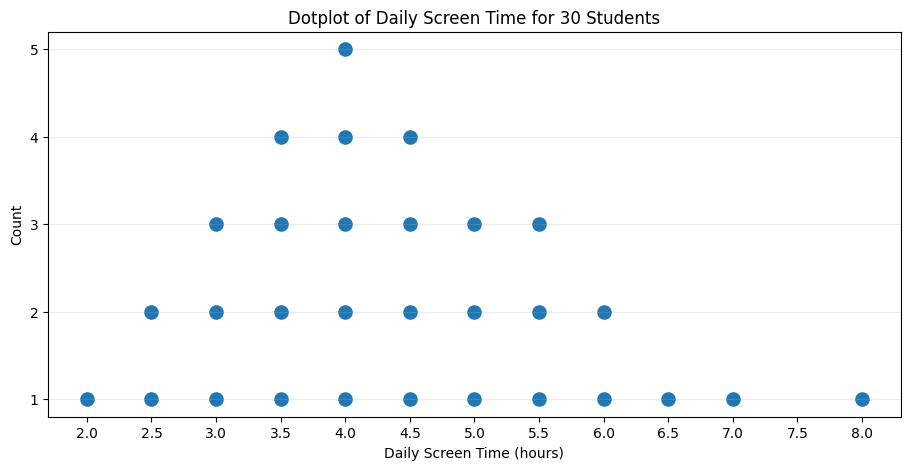

In [8]:
import matplotlib.pyplot as plt

# Count how many times each value appears
counts = {}

x_points = []
y_points = []

for value in dotplot_data:

    counts[value] = counts.get(value, 0) + 1

    x_points.append(value)
    y_points.append(counts[value])


# Create the dotplot
plt.figure(figsize=(11, 5))

plt.scatter(
    x_points,
    y_points,
    s=90
)

plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Count")

plt.title("Dotplot of Daily Screen Time for 30 Students")

# Show count values clearly on the y-axis
plt.yticks(range(1, max(y_points) + 1))

# Make the x-axis easier to read
plt.xticks(
    [2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8]
)

plt.grid(axis="y", alpha=0.25)

plt.show()

## 🌿 Stem-and-Leaf Plot

A **stem-and-leaf plot** also preserves individual observations while organizing them to reveal the distribution.

For the values below:

- the **stem** represents the whole number of hours;
- the **leaf** represents the tenths digit.

Example:

`4 | 7` represents **4.7 hours**.

In [23]:
values = np.sort((small_sample * 10).round().astype(int))

stems = {}
for value in values:
    stem = value // 10
    leaf = value % 10
    stems.setdefault(stem, []).append(leaf)

stem_leaf_table = pd.DataFrame({
    "Stem (hours)": list(stems.keys()),
    "Leaves (tenths)": [" ".join(map(str, leaves)) for leaves in stems.values()]
})

display(stem_leaf_table.style.hide(axis="index"))

Stem (hours),Leaves (tenths)
2,2 4 5 7 8 9
3,3 4 5 6 7 8 9
4,4 6
5,1 1 2 6 8
6,4 6 7 8 9
7,5
8,6 7
9,1
12,9


### 🔎 Compare the Displays

Think about the **dotplot, stem-and-leaf plot, histogram, and boxplot**.

1. Which displays preserve individual observations?
2. Which makes the overall shape easiest to see?
3. Which gives the most compact summary?
4. Which makes potential outliers easiest to notice?
5. Why might a histogram be more practical for our full dataset of 600 observations?

# 🔍 Clusters and Gaps — Can Data Form Groups?

Sometimes observations are not distributed smoothly across the entire range.

Instead, many observations may concentrate in particular regions.

This concentration is called a **cluster**.

> **Cluster:** A region of the distribution where many observations are concentrated.

We may also find regions containing few or no observations.

> **Gap:** An interval in the distribution containing no observations (or noticeably fewer observations).

Let's look at an example.

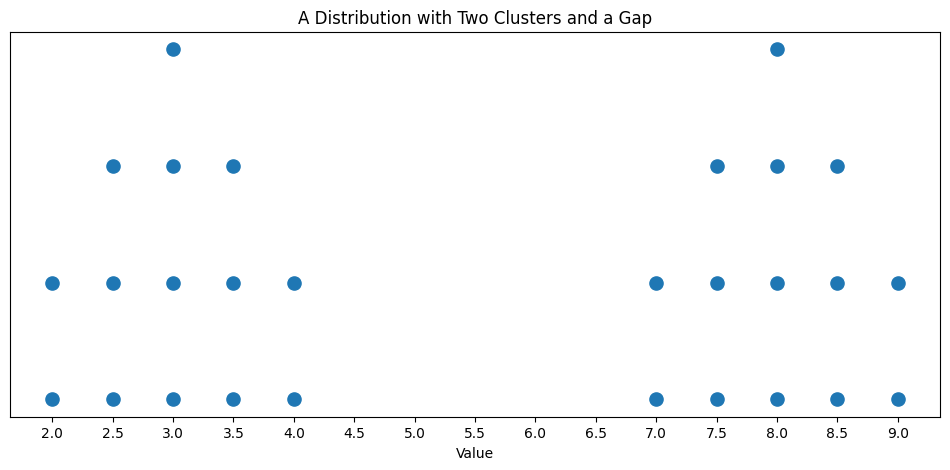

In [12]:
cluster_data = [
    # Cluster 1
    2.0, 2.0,
    2.5, 2.5, 2.5,
    3.0, 3.0, 3.0, 3.0,
    3.5, 3.5, 3.5,
    4.0, 4.0,

    # Cluster 2
    7.0, 7.0,
    7.5, 7.5, 7.5,
    8.0, 8.0, 8.0, 8.0,
    8.5, 8.5, 8.5,
    9.0, 9.0
]

# Stack repeated observations
counts = {}
x_points = []
y_points = []

for value in cluster_data:
    counts[value] = counts.get(value, 0) + 1
    x_points.append(value)
    y_points.append(counts[value])

plt.figure(figsize=(12, 5))

plt.scatter(
    x_points,
    y_points,
    s=90
)

plt.xlabel("Value")
plt.title("A Distribution with Two Clusters and a Gap")

plt.xticks(np.arange(2, 9.5, 0.5))
plt.yticks([])

plt.show()

## 👀 What Do You Notice?

There appear to be **two groups of observations**.

### Cluster 1
Many observations are concentrated approximately between **2 and 4**.

### Cluster 2
Another group is concentrated approximately between **7 and 9**.

### Gap
There are **no observations between 4 and 7**.

So we could describe the distribution as having:

> **Two clear clusters separated by a large gap.**

---

## 🧠 Why Are Clusters Important?

Finding a cluster is not the end of the investigation.

A statistician should ask:

> **Why might these groups exist?**

For example, two clusters could indicate that our data contain observations from **two different groups or populations**.

The graph can reveal the pattern, but additional information about the data is needed to explain **why** the clusters exist.

# ⚠️ Another Way to Flag an Unusual Observation

Earlier, we used the **1.5 × IQR rule** to identify potential outliers.

Another useful way to judge whether an observation is far from the center is to ask whether it lies more than **2 standard deviations from the mean**.

Let's calculate those boundaries.

In [ ]:
lower_2sd = screen.mean() - 2 * screen.std()
upper_2sd = screen.mean() + 2 * screen.std()

print(f"Mean - 2 SD: {lower_2sd:.2f} hours")
print(f"Mean + 2 SD: {upper_2sd:.2f} hours")

far_from_mean = screen[(screen < lower_2sd) | (screen > upper_2sd)]

display(
    far_from_mean.to_frame(name="Screen Time (hours)")
    .style.hide(axis="index")
)

# ⚖️ Comparing Two Quantitative Distributions

Statisticians often need to compare two distributions rather than describe only one.

A good comparison discusses:

- **Center**
- **Variability**
- **Shape**
- **Unusual features**

And most importantly, the comparison must be made **in context**.

Let's compare **screen time** and **sleep time** visually.

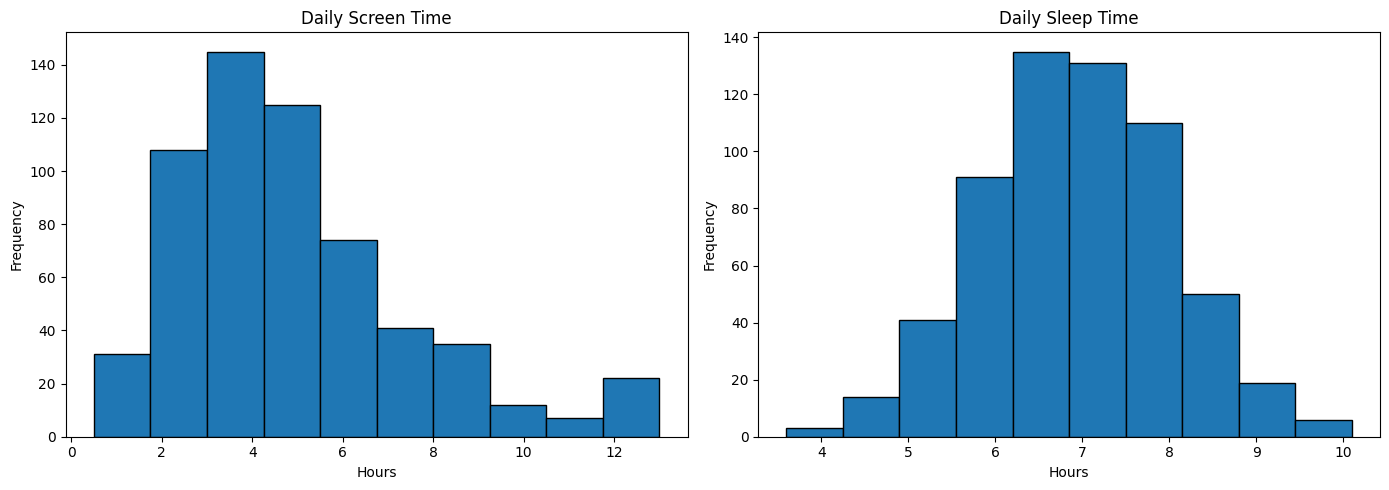

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Screen_Time_Hours"], bins=10, edgecolor="black")
axes[0].set_title("Daily Screen Time")
axes[0].set_xlabel("Hours")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["Sleep_Hours"], bins=10, edgecolor="black")
axes[1].set_title("Daily Sleep Time")
axes[1].set_xlabel("Hours")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [10]:
comparison_summary = pd.DataFrame({
    "Measure": ["Mean", "Median", "IQR", "Standard Deviation"],
    "Screen Time": [
        df["Screen_Time_Hours"].mean(),
        df["Screen_Time_Hours"].median(),
        df["Screen_Time_Hours"].quantile(.75) - df["Screen_Time_Hours"].quantile(.25),
        df["Screen_Time_Hours"].std()
    ],
    "Sleep Time": [
        df["Sleep_Hours"].mean(),
        df["Sleep_Hours"].median(),
        df["Sleep_Hours"].quantile(.75) - df["Sleep_Hours"].quantile(.25),
        df["Sleep_Hours"].std()
    ]
})

display(
    comparison_summary.style
    .format({"Screen Time": "{:.2f}", "Sleep Time": "{:.2f}"})
    .hide(axis="index")
)

Measure,Screen Time,Sleep Time
Mean,4.92,6.90
Median,4.40,6.90
IQR,3.12,1.40
Standard Deviation,2.61,1.07


### ✍️ Comparison Challenge

Write a short paragraph comparing the two distributions.

Do **not** write two separate descriptions.

Use comparative language such as:

- greater than / less than
- more variable / less variable
- more symmetric / more skewed
- has more / fewer unusual observations

Remember to refer to **screen time and sleep time**, not just “Distribution A” and “Distribution B.”

# 🎯 Z-Scores — Comparing Relative Position

Sometimes we want to compare observations from **different distributions**.

For example:

> Is **8 hours of screen time** more unusual than **9 hours of sleep**?

We cannot answer this simply by comparing 8 and 9 because the two variables have different centers and spreads.

A **z-score** tells us how many standard deviations an observation is above or below its mean.

For sample data:

$$
z=\frac{x-\bar{x}}{s}
$$

where:

- $x$ = the observation
- $\bar{x}$ = sample mean
- $s$ = sample standard deviation

### Interpretation

- $z=0$: exactly at the mean
- $z>0$: above the mean
- $z<0$: below the mean
- larger $|z|$: farther from the mean

In [11]:
screen_value = 8
sleep_value = 9

z_screen = (screen_value - df["Screen_Time_Hours"].mean()) / df["Screen_Time_Hours"].std()
z_sleep = (sleep_value - df["Sleep_Hours"].mean()) / df["Sleep_Hours"].std()

z_table = pd.DataFrame({
    "Observation": ["8 hours Screen Time", "9 hours Sleep"],
    "Z-score": [z_screen, z_sleep]
})

display(z_table.style.format({"Z-score": "{:.2f}"}).hide(axis="index"))

Observation,Z-score
8 hours Screen Time,1.18
9 hours Sleep,1.96


### 🧠 Which Observation Is More Unusual?

Compare the **absolute values** of the two z-scores.

The observation with the larger absolute z-score is farther from its own distribution's mean in standard-deviation units.

### AP-Style Interpretation

A z-score should be interpreted in context.

For example:

> A z-score of 1.6 means the student's value is **1.6 standard deviations above the mean** for that variable.

# 🏁 Final Quantitative Data Investigation

Choose **one quantitative variable** from the dataset and prepare a short statistical report.

Your report should:

1. Choose an appropriate graphical display.
2. Describe the **shape**.
3. Describe an appropriate measure of **center**.
4. Describe **variability**.
5. Identify any **gaps, clusters, or potential outliers**.
6. Decide whether **mean & standard deviation** or **median & IQR** provide the more appropriate summary.
7. Calculate and interpret at least one **percentile or z-score**.
8. Write a final conclusion **in context**.

> ### Your goal is not to produce as many calculations as possible.
>
> Your goal is to use the calculations and graphs that best help you **understand and communicate the distribution**.